In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="dJPhE0l9S0VAHFY6mqwJ")
project = rf.workspace("culture-and-science-city").project("face-recognition-djybb")
version = project.version(6)
dataset = version.download("multiclass")

loading Roboflow workspace...
loading Roboflow project...


In [1]:
import pandas as pd



train_csv_path = '/mnt/d/malak/sss_ai/Face-Recognition-6/train/_classes.csv'
train_img_dir = '/mnt/d/malak/sss_ai/Face-Recognition-6/train/'
valid_csv_path = '/mnt/d/malak/sss_ai/Face-Recognition-6/valid/_classes.csv'
valid_img_dir = '/mnt/d/malak/sss_ai/Face-Recognition-6/valid/'
test_csv_path = '/mnt/d/malak/sss_ai/Face-Recognition-6/test/_classes.csv'
test_img_dir = '/mnt/d/malak/sss_ai/Face-Recognition-6/test/'

df_train = pd.read_csv(train_csv_path)
df_valid = pd.read_csv(valid_csv_path)
df_test = pd.read_csv(test_csv_path)
print(df_train.head()) 
print(df_valid.head())
print(df_test.head()) 

                                            filename  Person1  Person2  \
0  aug_0af45e698c364d4e9b0141eb5cfe97be_jpg.rf.ab...        0        1   
1  aug_e7636813fd0d4dd8bded608f01985421_jpg.rf.d8...        1        0   
2  aug_d25c336687434447b25e0c41d613692a_jpg.rf.93...        1        0   
3  aug_0116eecfab404e2b9757b8de9b28fe38_jpg.rf.ad...        0        0   
4  aug_eab265f1f5bf45cf876ec975c0e96a01_jpg.rf.a8...        1        0   

   Person3  Person4  
0        0        0  
1        0        0  
2        0        0  
3        1        0  
4        0        0  
                                            filename  Person1  Person2  \
0  aug_a93d3d4a978546b3ad43dae2364ec552_jpg.rf.3f...        0        0   
1  aug_787fbd32a0a144d39b2edc59464f267c_jpg.rf.9e...        0        1   
2  aug_348a9849c1c14d60a67787c8faaad850_jpg.rf.83...        0        0   
3  aug_042f8b7dec834ddd924e014454b3ac2f_jpg.rf.a2...        0        0   
4  aug_af792ae448f049cdae8052833369a44d_jpg.rf.07... 

In [2]:
# 1. تحويل الـ One-Hot Encoding لعمود واحد فيه اسم الشخص
def get_class_name(row):
    for col in columns:
        if row[col] == 1:
            return col
    return None

columns = ['Person1', 'Person2', 'Person3', 'Person4']

df_train['class'] = df_train.apply(get_class_name, axis=1)
df_valid['class'] = df_valid.apply(get_class_name, axis=1)
df_test['class'] = df_test.apply(get_class_name, axis=1)



In [5]:
import pandas as pd

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

import matplotlib.pyplot as plt



# --- 1. تجهيز الـ DataFrames (تحويل الـ One-Hot لـ String) ---

columns = ['Person1', 'Person2', 'Person3', 'Person4']



def get_class_name(row):

    for col in columns:

        if row[col] == 1:

            return col

    return None



# تطبيق التحويل على الجداول

df_train['class'] = df_train.apply(get_class_name, axis=1)

df_valid['class'] = df_valid.apply(get_class_name, axis=1)

df_test['class'] = df_test.apply(get_class_name, axis=1)



# --- 2. إعداد الـ Data Generators ---

datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,      

    width_shift_range=0.2,

    height_shift_range=0.2,

    shear_range=0.2,      

    zoom_range=0.2,        

    horizontal_flip=True,  

    fill_mode='nearest'

)



train_generator = datagen.flow_from_dataframe(

    dataframe=df_train,

    directory=train_img_dir,

    x_col="filename",

    y_col="class",

    target_size=(224, 224),

    batch_size=32,

    class_mode="categorical"

)



valid_generator = datagen.flow_from_dataframe(

    dataframe=df_valid,

    directory=valid_img_dir,

    x_col="filename",

    y_col="class",

    target_size=(224, 224),

    batch_size=32,

    class_mode="categorical"

)



test_generator = datagen.flow_from_dataframe(

    dataframe=df_test,

    directory=test_img_dir,

    x_col="filename",

    y_col="class",

    target_size=(224, 224),

    batch_size=32,

    class_mode="categorical",

    shuffle=False

)

Found 696 validated image filenames belonging to 4 classes.
Found 149 validated image filenames belonging to 4 classes.
Found 149 validated image filenames belonging to 4 classes.


In [6]:
print(train_generator.class_indices)
print(valid_generator.class_indices)
print(test_generator.class_indices)

{'Person1': 0, 'Person2': 1, 'Person3': 2, 'Person4': 3}
{'Person1': 0, 'Person2': 1, 'Person3': 2, 'Person4': 3}
{'Person1': 0, 'Person2': 1, 'Person3': 2, 'Person4': 3}


In [9]:
import joblib
import tensorflow as tf


feature_extractor = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), 
    include_top=False, 
    weights='imagenet', 
    pooling='avg'      
    )



print("✅ Feature Extractor (MobileNetV2) & SVM are READY!")



✅ Feature Extractor (MobileNetV2) & SVM are READY!


In [10]:
import numpy as np

def extract_embeddings(generator, model):
	features = []
	labels = []
	for i in range(len(generator)):
		imgs, lbls = generator[i]
		feats = model.predict(imgs, verbose=0)
		features.append(feats)
		labels.append(lbls)
	features = np.concatenate(features)
	labels = np.concatenate(labels)
	labels = np.argmax(labels, axis=1)  
	return features, labels

# تأكدي إن الـ feature_extractor متعرف بـ pooling='avg'
print("⏳ Re-extracting features with 1280 size...")
X_train_new, y_train_new = extract_embeddings(train_generator, feature_extractor)


print(f"✅ New Shape: {X_train_new.shape}")

⏳ Re-extracting features with 1280 size...


I0000 00:00:1776188791.488758    4889 service.cc:152] XLA service 0x7f3e2010f910 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776188791.488802    4889 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2026-04-14 19:46:31.586613: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776188792.109911    4889 cuda_dnn.cc:529] Loaded cuDNN version 92000
I0000 00:00:1776188799.733135    4889 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


✅ New Shape: (696, 1280)


In [11]:
from sklearn.svm import SVC
import joblib

# تدريب الموديل
clf = SVC(kernel='linear', probability=True)
clf.fit(X_train_new, y_train_new)

joblib.dump(clf, 'face_svm_model.pkl')
print("✅ SVM Retrained and Saved successfully!")

✅ SVM Retrained and Saved successfully!


⏳ Adjusting Test features size to 1280...
✅ Adjusted Shape: (149, 1280)
📊 Classification Report for SSS:
              precision    recall  f1-score   support

     Person1       1.00      1.00      1.00        39
     Person2       1.00      1.00      1.00        35
     Person3       1.00      1.00      1.00        38
     Person4       1.00      1.00      1.00        37

    accuracy                           1.00       149
   macro avg       1.00      1.00      1.00       149
weighted avg       1.00      1.00      1.00       149



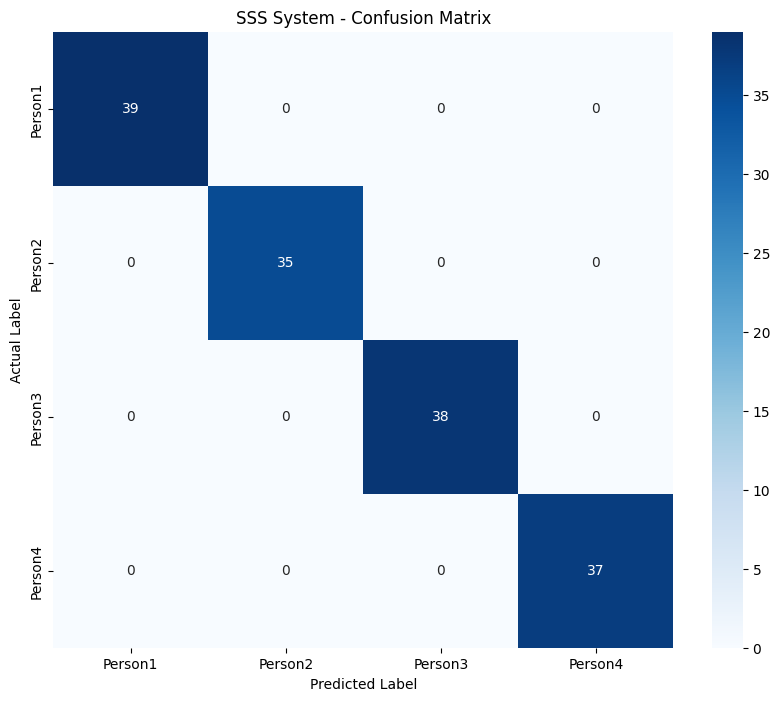

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("⏳ Adjusting Test features size to 1280...")
X_test_features, y_test = extract_embeddings(test_generator, feature_extractor)

print(f"✅ Adjusted Shape: {X_test_features.shape}") 


y_pred = clf.predict(X_test_features)
class_names = columns

print("📊 Classification Report for SSS:")
print(classification_report(y_test, y_pred, target_names=class_names))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('SSS System - Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

In [13]:
import time

start_time = time.time()
# ... خطوات الـ Prediction ...
end_time = time.time()

latency = (end_time - start_time) * 1000 
print(f"⏱️ Inference Speed: {latency:.2f} ms")

⏱️ Inference Speed: 0.01 ms


In [14]:
import pandas as pd
import os
import cv2
import numpy as np
import joblib
from sklearn.metrics import accuracy_score

# 1. المسارات (تأكدي إنها للملف الأصلي)
base_path = '/mnt/d/malak/sss_ai/face-recognition-6/test'
csv_path = os.path.join(base_path, '_classes.csv')

# تحميل الداتا والموديل
df_classes = pd.read_csv(csv_path)
df_classes.columns = df_classes.columns.str.strip()
clf = joblib.load('face_svm_model.pkl')

y_true, y_pred, confidences = [], [], []

print(f"🚀 Analyzing {len(df_classes)} images...")

for index, row in df_classes.iterrows():
    img_name = row['filename'].strip()
    img_path = os.path.join(base_path, img_name)
    
    if os.path.exists(img_path):
        img = cv2.imread(img_path)
        if img is not None:
            # معالجة الصورة
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_resized = cv2.resize(img_rgb, (224, 224))
            img_array = np.expand_dims(img_resized / 255.0, axis=0)
            
            # التوقع
            embedding = feature_extractor.predict(img_array, verbose=0)
            probs = clf.predict_proba(embedding)
            
            # حفظ النتائج في لستة (مش في الملف)
            y_true.append(np.argmax(row[1:].values))
            y_pred.append(np.argmax(probs))
            confidences.append(np.max(probs))

# عرض النتائج
print(f"✅ Accuracy: {accuracy_score(y_true, y_pred)*100:.2f}%")
print(f"🛡️ Avg Confidence: {np.mean(confidences)*100:.2f}%")

# --- الخطوة السحرية ---
# هنا هنضيف عمود الـ Confidence للـ DataFrame في الذاكرة بس عشان نعرضه في الـ Dashboard
df_classes['Confidence'] = [f"{c*100:.2f}%" for c in confidences]
# لو عايزة تسيفيه في ملف جديد منفصل للتحليل (اختياري):
df_classes.to_csv(os.path.join(base_path, 'analysis_results.csv'), index=False)

🚀 Analyzing 149 images...
✅ Accuracy: 100.00%
🛡️ Avg Confidence: 99.22%


In [17]:
import tensorflow as tf
model = tf.keras.models.load_model('/mnt/d/malak/sss_ai/sss_face_model.h5')
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)

INFO:tensorflow:Assets written to: /tmp/tmp7omehjxe/assets


INFO:tensorflow:Assets written to: /tmp/tmp7omehjxe/assets


Saved artifact at '/tmp/tmp7omehjxe'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  139905474178112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139905474255632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139905474257744: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139905474251056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139905474253344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139905474261616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139905474261792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139905474263552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139905474260384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139905474262848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1399054742602

W0000 00:00:1776190754.163980    3877 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1776190754.164026    3877 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2026-04-14 20:19:14.164874: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp7omehjxe
2026-04-14 20:19:14.172220: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-04-14 20:19:14.172242: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp7omehjxe
I0000 00:00:1776190754.243365    3877 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
2026-04-14 20:19:14.257875: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-04-14 20:19:14.677083: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp7omehjxe
2026-04-14 20:19:14.781668: I tensorflow/cc/saved_model/loader.cc:471] SavedModel 

In [ ]:
import joblib
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

# 1. تحميل موديل الـ SVM بتاعك
clf = joblib.load('face_svm_model.pkl')

# 2. تعريف حجم البيانات المدخلة (الـ 1280 ميزة اللي اتفقنا عليهم)
initial_type = [('float_input', FloatTensorType([None, 1280]))]

# 3. تحويل الموديل لصيغة ONNX
onx = convert_sklearn(clf, initial_types=initial_type)

# 4. حفظ الملف الجديد
with open("face_svm_model.onnx", "wb") as f:
    f.write(onx.SerializeToString())

print("✅ Model successfully converted to ONNX!")


NameError: name 'cite' is not defined